<a href="https://colab.research.google.com/github/simsekergun/Waveguide_FEM_Solver/blob/main/WG_Module_Simple_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install waveguide-fem==1.1.2

In [2]:
from waveguide_fem import build_soi_mesh, compute_modes, get_refractive_index
from waveguide_fem import plot_mode_fields, calculate_overlap
import time
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigs
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

n_core (Si3N4) = 1.996280
n_clad (SiO2)  = 1.444024
Building mesh ...
  Mesh: 28116 nodes, 55130 elems  (core=2378, box=23471, clad=29281)
Nodes: 28116,  Elements: 55130
Assembling & solving eigenvalue problem ...
  DOFs: 83245 edge (Et) + 28116 nodal (Ez) = 111361 total
  Running eigs (k=6, sigma=72.0331) ...

n_eff values:
  (1.8122474973168479-5.1779099599280245e-17j)
  (1.7698474125634927+1.9202419607374138e-16j)
  (1.6651013117930569-5.721082329803183e-17j)
  (1.644212435058309+2.958684669667142e-16j)
  (1.4647870846065612-3.691346612344002e-18j)
  (1.4579520775221688+2.383047822067902e-14j)
Elapsed: 86.92 s

--- Guided modes ---
Mode 1:  n_eff = 1.812247 + -5.18e-17i,  TE-frac = 0.999
Mode 2:  n_eff = 1.769847 + 1.92e-16i,  TE-frac = 0.004
Mode 3:  n_eff = 1.665101 + -5.72e-17i,  TE-frac = 0.993
Mode 4:  n_eff = 1.644212 + 2.96e-16i,  TE-frac = 0.022
Mode 5:  n_eff = 1.464787 + -3.69e-18i,  TE-frac = 0.953
Mode 6:  n_eff = 1.457952 + 2.38e-14i,  TE-frac = 0.962
  Saved Mode_1_(fu

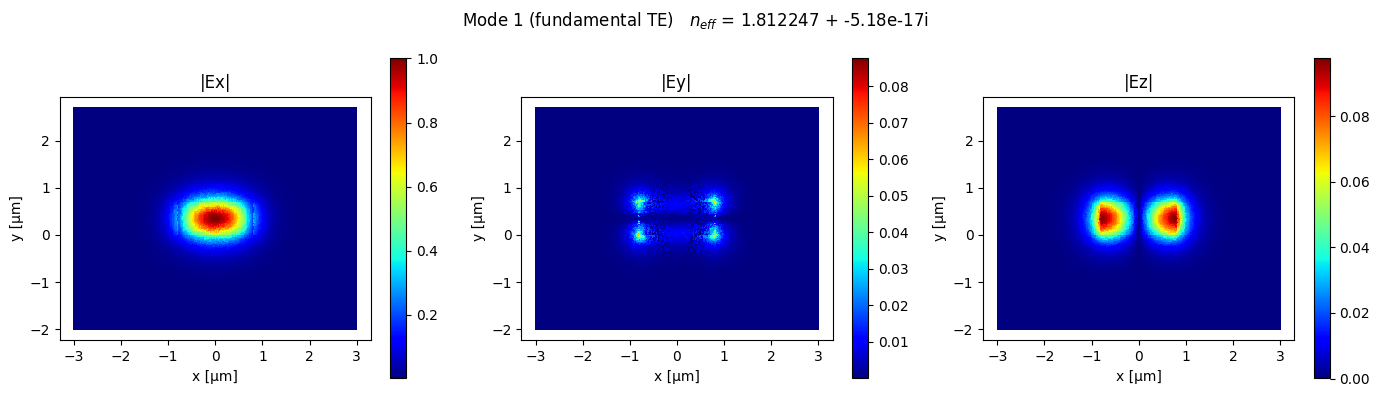

  Saved Mode_2.png


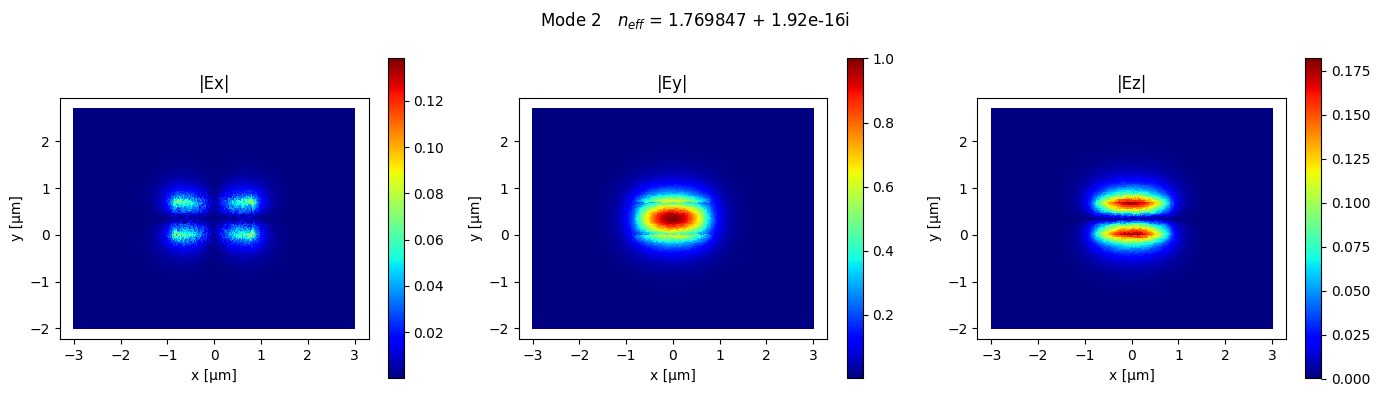

  Saved Mode_3.png


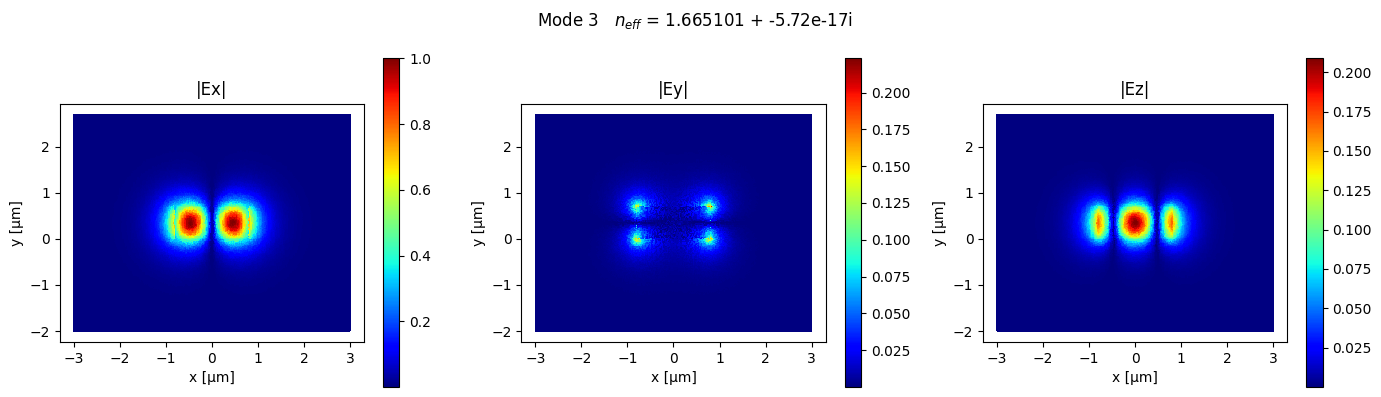

In [3]:
wavelength = 1.55   # µm

# Geometry (µm)
w_core = 1.6
h_core = 0.7
h_clad = 2.7
h_box  = 2.00
w_sim  = 6.00

n_core = get_refractive_index('Si3N4', wavelength)
n_clad = get_refractive_index('SiO2',  wavelength)
n_box  = n_clad

num_modes        = 6
mesh_res         = round(w_sim / wavelength * 80)

print(f"n_core (Si3N4) = {n_core:.6f}")
print(f"n_clad (SiO2)  = {n_clad:.6f}")

print("Building mesh ...")
nodes, elems, epsilon_r, regions = build_soi_mesh(
    w_core, h_core, h_clad, h_box, w_sim,
    n_core, n_clad, n_box, mesh_res)
print(f"Nodes: {nodes.shape[0]},  Elements: {elems.shape[0]}")

print("Assembling & solving eigenvalue problem ...")
t0 = time.perf_counter()
modes = compute_modes(nodes, elems, epsilon_r, wavelength,
                      num_modes=num_modes, mu_r=1.0)
print(f"Elapsed: {time.perf_counter() - t0:.2f} s")

# ---- Print results ----
print("\n--- Guided modes ---")
for m_idx, mode in enumerate(modes):
    print(f"Mode {m_idx + 1}:  n_eff = {np.real(mode['n_eff']):.6f} + "
          f"{np.imag(mode['n_eff']):.2e}i,  TE-frac = {mode['te_fraction']:.3f}")

# ---- Plot dominant modes ----
plot_mode_fields(modes[0], nodes, elems, 'Mode 1 (fundamental TE)')
plot_mode_fields(modes[1], nodes, elems, 'Mode 2')
plot_mode_fields(modes[2], nodes, elems, 'Mode 3')